# Load Dataset

In [1]:
import os
from pathlib import Path
from torch_geometric.datasets import QM9

DATA_ROOT = Path.cwd().parent / "data" / "QM9"

dataset = QM9(DATA_ROOT)

/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/torch_geometric/data/dataset.py:115: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


# Define EGNN

In [2]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing

class TypeGCN(MessagePassing):
    propagate_type = {"type_feat": torch.Tensor, "edge_attr": torch.Tensor}

    def __init__(
        self, hidden_nf: int, attention: bool = True, aggr_type: str = "sum"
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2
        self.message_mlp = nn.Sequential(
            nn.Linear(in_message_dim, in_message_dim),
            nn.SiLU(),
            nn.Linear(in_message_dim, hidden_nf),
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_nf * 2, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
        )

        self.attention = attention
        if self.attention:
            self.att_mlp = nn.Sequential(
                nn.Linear(hidden_nf, 1),
                nn.Sigmoid(),
            )

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor
    ) -> torch.Tensor:
        input_tensor = torch.cat(
            [type_feat_i, type_feat_j, edge_attr],
            dim=-1,
        )
        out = self.message_mlp(input_tensor)

        if self.attention:
            att_val = self.att_mlp(out)
            return out * att_val

        return out

    def update(self, aggr_out: torch.Tensor, type_feat: torch.Tensor) -> torch.Tensor:
        out = torch.cat([aggr_out, type_feat], dim=-1)
        return type_feat + self.update_mlp(out)

    def forward(
        self, type_feat: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor
    ) -> torch.Tensor:
        return self.propagate(
            edge_index, type_feat=type_feat, edge_attr=edge_attr
        )


class PosGCN(MessagePassing):
    propagate_type = {
        "type_feat": torch.Tensor,
        "scaled_dir_vector": torch.Tensor,
        "edge_attr": torch.Tensor,
    }

    def __init__(
        self,
        hidden_nf: int,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2

        layer = nn.Linear(hidden_nf, 1, bias=False)
        torch.nn.init.xavier_uniform_(layer.weight, gain=0.001)

        self.coord_mlp = nn.Sequential(
            nn.Linear(in_message_dim, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
            nn.SiLU(),
            layer,
        )

        self.tanh_coord_updates = tanh_coord_updates
        self.coords_range = coords_range

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        input_tensor = torch.cat([type_feat_i, type_feat_j, edge_attr], dim=-1)
        weight = self.coord_mlp(input_tensor)
        if self.tanh_coord_updates:
            weight = torch.tanh(weight) * self.coords_range
        return scaled_dir_vector * weight

    def forward(
        self,
        pos: torch.Tensor,
        type_feat: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        delta = self.propagate(
            edge_index,
            type_feat=type_feat,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )
        return pos + delta


class EquivariantBlock(nn.Module):
    def __init__(
        self,
        hidden_nf: int,
        n_layers: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()

        self.type_update = nn.ModuleList(
            [
                TypeGCN(hidden_nf, attention=attention, aggr_type=aggr_type)
                for _ in range(n_layers)
            ]
        )

        self.coord_update = PosGCN(
            hidden_nf,
            tanh_coord_updates=tanh_coord_updates,
            coords_range=coords_range,
            aggr_type=aggr_type,
        )

    def forward(
        self,
        type_feat: torch.Tensor,
        pos: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        for type_gcn in self.type_update:
            type_feat = type_gcn(
                type_feat=type_feat,
                edge_index=edge_index,
                edge_attr=edge_attr
            )

        pos = self.coord_update(
            pos=pos,
            type_feat=type_feat,
            edge_index=edge_index,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )

        return type_feat, pos

def compute_edge_properties(
    pos: torch.Tensor, edge_index: torch.Tensor, norm_constant: float = 1.0
) -> tuple[torch.Tensor, torch.Tensor]:
    src, dst = edge_index
    dist = pos[src] - pos[dst]
    squared_norm = dist.pow(2).sum(dim=-1)
    norm = squared_norm.sqrt()
    scaled_dir_vector = dist / (norm.unsqueeze(-1) + norm_constant)
    return squared_norm, scaled_dir_vector

class EGNN(nn.Module):
    def __init__(
        self,
        num_atom_types: int,
        num_blocks: int = 9,
        hidden_nf: int = 256,
        num_layers_per_block: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()
        # Main difference with original EGNN is that we have an Embedding layer
        # here instead of a regular linear layer
        self.type_embedding = nn.Embedding(num_atom_types, hidden_nf)
        # Also, we remove the type_embedding_out layer since we don't need to
        # output the type logits for the generated molecule
        self.blocks = nn.ModuleList(
            [
                EquivariantBlock(
                    hidden_nf,
                    n_layers=num_layers_per_block,
                    attention=attention,
                    tanh_coord_updates=tanh_coord_updates,
                    coords_range=coords_range,
                    aggr_type=aggr_type,
                )
                for _ in range(num_blocks)
            ]
        )

    def forward(
        self,
        pos_noise: torch.Tensor,
        atom_type: torch.Tensor,
        edge_index: torch.Tensor,
        return_change_in_pos: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        gen_feats = self.type_embedding(atom_type)
        gen_pos = pos_noise
        initial_squared_norm, _ = compute_edge_properties(gen_pos, edge_index)

        pos_list = []
        if return_change_in_pos:
            pos_list.append(gen_pos.clone())

        for block in self.blocks:
            squared_norm, scaled_dir_vector = compute_edge_properties(gen_pos, edge_index)
            edge_attr = torch.cat(
                [initial_squared_norm.unsqueeze(-1), squared_norm.unsqueeze(-1)],
                dim=-1,
            )
            # NOTE: the block updates both the positions and the type features,
            # I am unsure if we really need to update the type features, since we are not
            # using them for anything after the initial embedding layer.
            # Perhaps this helps us learn better position updates.
            gen_feats, gen_pos = block(
                type_feat=gen_feats,
                pos=gen_pos,
                edge_index=edge_index,
                scaled_dir_vector=scaled_dir_vector,
                edge_attr=edge_attr,
            )
            if return_change_in_pos:
                pos_list.append(gen_pos.clone())

        if return_change_in_pos:
            return gen_pos, pos_list
        return gen_pos

# Drifting Fields

In [30]:

def compute_euclidean_drifting_field(gen_mol, real_mol, sigma = 1.0):
    n_gen = gen_mol.size(0)
    n_real = real_mol.size(0)

    targets = torch.cat([gen_mol, real_mol], dim=0)

    # [N_gen, N_targets, D]
    diffs = targets.unsqueeze(0) - gen_mol.unsqueeze(1)

    # [N_gen, N_targets]
    sq_dists = (diffs * diffs).sum(dim=-1)

    # [N_gen, N_targets]
    kernel = torch.exp(-sq_dists / (2 * sigma**2))

    # [N_gen, N_gen], [N_gen, N_real]
    kernel_neg, kernel_pos = torch.split(kernel, [n_gen, n_real], dim=1)
    # [N_gen, N_gen, D], [N_gen, N_real, D]
    diffs_neg, diffs_pos = torch.split(diffs, [n_gen, n_real], dim=1)

    # Weigh diffs, [N_gen, N_gen, D]
    weighted_neg = kernel_neg.unsqueeze(-1) * diffs_neg
    weighted_pos = kernel_pos.unsqueeze(-1) * diffs_pos

    # [N_gen, 1]
    Z_neg = kernel_neg.sum(dim=1, keepdim=True)
    Z_pos = kernel_pos.sum(dim=1, keepdim=True)

    # [N_gen, D]
    v_neg = weighted_neg.sum(dim=1) / (Z_neg + 1e-8)
    v_pos = weighted_pos.sum(dim=1) / (Z_pos + 1e-8)

    return v_pos - v_neg

# Ops/Aux fns

In [4]:
from torch_geometric.nn import global_mean_pool

def get_sorted_mols(gen_mols, real_mol):
    dists = torch.cdist(gen_mols, real_mol)
    closest_indices = torch.argsort(dists, dim=0)
    return gen_mols[closest_indices], closest_indices

def center_positions_per_mol(
    pos: torch.Tensor, batch_vec: torch.Tensor = None
) -> torch.Tensor:
    """Zero-center coordinates independently for each graph in a batch."""
    if batch_vec is None:
        return pos - pos.mean(dim=0, keepdim=True)
    com = global_mean_pool(pos, batch_vec)  # [G, 3]
    return pos - com[batch_vec]

# Viz Fns

In [5]:
import matplotlib.pyplot as plt
import torch

def visualize_both_molecules(gen_pos: torch.Tensor, real_pos: torch.Tensor):
    gen_pos = gen_pos.view(-1, 3).detach().cpu().numpy()
    real_pos = real_pos.view(-1, 3).detach().cpu().numpy()

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(gen_pos[:, 0],  gen_pos[:, 1],  gen_pos[:, 2],  color='red',  label='Generated', alpha=0.8)
    ax.scatter(real_pos[:, 0], real_pos[:, 1], real_pos[:, 2], color='blue', label='Real',      alpha=0.8)

    ax.set_title('Generated vs Real Molecule')
    ax.legend()
    plt.show()

def _apply_limits(ax, x_lim, y_lim, z_lim):
    ax.set_autoscale_on(False)
    ax.set_xlim3d(*x_lim)
    ax.set_ylim3d(*y_lim)
    ax.set_zlim3d(*z_lim)


def _plot_molecule(ax, pos, types, title='', limits=None):
    """Scatter-plots a single molecule onto an existing 3-D axis."""
    if limits is not None:
        ax.set_autoscale_on(False)          # lock before any scatter call
        ax.set_xlim3d(*limits[0])
        ax.set_ylim3d(*limits[1])
        ax.set_zlim3d(*limits[2])

    pos_np = pos.view(-1, 3).detach().cpu().numpy()
    types_r = torch.round(types, decimals=0)

    for atom_type in torch.unique(types_r):
        mask = (types_r == atom_type).cpu().numpy()
        ax.scatter(pos_np[mask, 0], pos_np[mask, 1], pos_np[mask, 2],
                   label=f'Type {atom_type.item()}')

    ax.set_title(title)
    ax.legend(fontsize=7)


def visualize_progression_with_real(
    pos_list: list[torch.Tensor],
    gen_types: torch.Tensor,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    step_indices: list[int] | None = None,
    max_steps: int = 5
):
    if step_indices is None:
        total = len(pos_list)
        step_indices = [int(i * (total - 1) / (max_steps - 1)) for i in range(max_steps)]

    # --- Compute consistent limits from ALL positions (trajectory + real) ---
    all_pos = torch.cat(
        [p.view(-1, 3) for p in pos_list] + [real_pos.view(-1, 3)]
    ).detach().cpu().numpy()

    padding = 0.5
    limits = (
        (all_pos[:, 0].min() - padding, all_pos[:, 0].max() + padding),
        (all_pos[:, 1].min() - padding, all_pos[:, 1].max() + padding),
        (all_pos[:, 2].min() - padding, all_pos[:, 2].max() + padding),
    )

    def _enforce_limits(ax):
        ax.set_autoscale_on(False)
        ax.set_xlim3d(*limits[0])
        ax.set_ylim3d(*limits[1])
        ax.set_zlim3d(*limits[2])

        ax.set_xticks([int(t) for t in range(int(limits[0][0]), int(limits[0][1]) + 1)])
        ax.set_yticks([int(t) for t in range(int(limits[1][0]), int(limits[1][1]) + 1)])
        ax.set_zticks([int(t) for t in range(int(limits[2][0]), int(limits[2][1]) + 1)])

    n_cols = len(step_indices) + 2
    fig = plt.figure(figsize=(4 * n_cols, 4))

    # --- Generated snapshots ---
    for plot_idx, step_idx in enumerate(step_indices):
        ax = fig.add_subplot(1, n_cols, plot_idx + 1, projection='3d')
        _plot_molecule(ax, pos_list[step_idx], gen_types, title=f'Step {step_idx}')
        _enforce_limits(ax)

    # --- Real molecule with atom types ---
    ax_real = fig.add_subplot(1, n_cols, n_cols - 1, projection='3d')
    _plot_molecule(ax_real, real_pos, real_types, title='Real Molecule')
    _enforce_limits(ax_real)

    # --- Overlap: final generated vs real ---
    ax_overlap = fig.add_subplot(1, n_cols, n_cols, projection='3d')
    final_pos = pos_list[-1].view(-1, 3).detach().cpu().numpy()
    real_pos_np = real_pos.view(-1, 3).detach().cpu().numpy()
    ax_overlap.scatter(final_pos[:, 0],   final_pos[:, 1],   final_pos[:, 2],   color='red',  label='Generated', alpha=0.8)
    ax_overlap.scatter(real_pos_np[:, 0], real_pos_np[:, 1], real_pos_np[:, 2], color='blue', label='Real',      alpha=0.8)
    ax_overlap.set_title('Final vs Real')
    ax_overlap.legend(fontsize=7)
    _enforce_limits(ax_overlap)

    plt.tight_layout()
    plt.show()


def visualize_both_molecules_with_atom_types(
    gen_pos, gen_types, real_pos, real_types
):
    fig = plt.figure(figsize=(12, 6))
    _plot_molecule(fig.add_subplot(121, projection='3d'), gen_pos,  gen_types,  'Generated Molecule')
    _plot_molecule(fig.add_subplot(122, projection='3d'), real_pos, real_types, 'Real Molecule')
    plt.show()


def plot_loss(loss_list):
    plt.plot(loss_list)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

# Kabsch

In [6]:
import torch
from torch_scatter import scatter_mean


def kabsch_align(P: torch.Tensor, Q: torch.Tensor) -> torch.Tensor:
    """
    Find rotation R and translation t that minimize ||R @ P.T + t - Q.T||^2,
    then return P aligned to Q.

    Args:
        P: [n_nodes, 3] source points (prediction)
        Q: [n_nodes, 3] target points

    Returns:
        P_aligned: [n_nodes, 3] - P after optimal rigid transform to match Q
    """
    # 1. Center both point clouds
    P_centroid = P.mean(dim=0, keepdim=True)  # [1, 3]
    Q_centroid = Q.mean(dim=0, keepdim=True)  # [1, 3]
    P_centered = P - P_centroid
    Q_centered = Q - Q_centroid

    # 2. Compute covariance matrix H = P_centered^T @ Q_centered
    H = P_centered.T @ Q_centered  # [3, 3]

    # 3. SVD: H = U @ S @ V^T
    U, S, Vt = torch.linalg.svd(H)

    # 4. Correct for reflection (ensure proper rotation, det = +1)
    d = torch.sign(torch.linalg.det(Vt.T @ U.T))
    D = torch.diag(torch.tensor([1.0, 1.0, d], device=P.device, dtype=P.dtype))

    # 5. Optimal rotation
    R = Vt.T @ D @ U.T  # [3, 3]

    # 6. Apply rotation and translate to Q's centroid
    P_aligned = (R @ P_centered.T).T + Q_centroid

    return P_aligned

def kabsch_align_pyg(P: torch.Tensor, Q: torch.Tensor,
                    batch: torch.Tensor, n_mols: int) -> torch.Tensor:
    """
    Vectorized Kabsch alignment for PyG-style flat layout with uniform mol size.

    Args:
        P: [N_total, 3] predictions
        Q: [N_total, 3] targets
        batch: [N_total] long tensor, molecule index per node
        n_mols: number of molecules in the batch

    Returns:
        P_aligned: [N_total, 3], each molecule rigidly aligned to its target
    """
    # 1. Per-molecule centroids and centering
    P_centroid = scatter_mean(P, batch, dim=0)  # [n_mols, 3]
    Q_centroid = scatter_mean(Q, batch, dim=0)  # [n_mols, 3]
    P_c = P - P_centroid[batch]                 # [N_total, 3]
    Q_c = Q - Q_centroid[batch]                 # [N_total, 3]

    # 2. Per-molecule covariance H_m = P_c_m^T @ Q_c_m, computed via scatter.
    # Outer product per node: [N_total, 3, 3], then sum within each molecule.
    outer = P_c.unsqueeze(2) * Q_c.unsqueeze(1)  # [N_total, 3, 3]
    H = scatter_mean(outer, batch, dim=0) * (outer.shape[0] / n_mols)
    H = H + 1e-4 * torch.eye(3, device=H.device).expand_as(H)

    # Note: scatter_mean gives the mean; multiplying by nodes-per-mol recovers
    # the sum. Since SVD's rotation is invariant to positive scaling of H,
    # you can actually skip this rescale — keeping it for clarity.

    # 3. Batched SVD
    U, S, Vt = torch.linalg.svd(H)  # all [n_mols, 3, 3]

    # 4. Reflection correction per molecule
    det = torch.linalg.det(Vt.transpose(-1, -2) @ U.transpose(-1, -2))  # [n_mols]
    D = torch.eye(3, device=P.device, dtype=P.dtype).expand(n_mols, -1, -1).clone()
    D[:, 2, 2] = torch.sign(det)

    R = Vt.transpose(-1, -2) @ D @ U.transpose(-1, -2)  # [n_mols, 3, 3]

    # 5. Apply rotation per node, then translate to target centroid
    R_per_node = R[batch]                                # [N_total, 3, 3]
    P_rot = torch.einsum('nij,nj->ni', R_per_node, P_c)  # [N_total, 3]
    P_aligned = P_rot + Q_centroid[batch]

    return P_aligned


def kabsch_mse_pyg(P, Q, batch, n_mols):
    P_aligned = kabsch_align_pyg(P, Q, batch, n_mols)
    return ((P_aligned - Q) ** 2).mean()

# Chemical Stability

In [7]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent ))

from model.mol_utils.validity import batch_to_validity
from model.mol_utils.stability import batch_to_stability, heavy_atom_counts

import torch
import numpy as np

def evaluate_generated_molecules(gen_pos: torch.Tensor, a_hard: torch.Tensor, batch_vec: torch.Tensor):

    results = batch_to_validity(gen_pos.detach().cpu(), a_hard.detach().cpu(), batch_vec.detach().cpu())
    heavy = heavy_atom_counts(a_hard.detach().cpu(), batch_vec.detach().cpu())
    atom_stable_frac, mol_stable_frac = batch_to_stability(gen_pos.detach().cpu(), a_hard.detach().cpu(), batch_vec.detach().cpu())

    n_total = len(results)
    n_valid = sum(1 for ok, _ in results if ok)
    valid_ids = [ident for ok, ident in results if ok and ident is not None]
    uniqueness = len(set(valid_ids)) / len(valid_ids) if valid_ids else 0.0
    validity = n_valid / n_total if n_total > 0 else 0.0
    heavy_mean = float(np.mean(heavy)) if heavy else 0.0

    print(f"Validity: {validity:.4f}, Uniqueness: {uniqueness:.4f}, Mean Heavy Atoms: {heavy_mean:.2f}")
    print(f"Atom Stability Fraction: {atom_stable_frac:.4f}, Molecule Stability Fraction: {mol_stable_frac:.4f}")

# Sample Noise - ONCE

Number of nodes: 29
Center of mass of real molecule positions: tensor([4.1107e-09, 8.2213e-09, 0.0000e+00], device='cuda:0')
Std of real molecule positions: tensor([1.0000, 1.0000, 1.0000], device='cuda:0')
Real molecule atom types shape: torch.Size([29])
Iter 99: Loss = 0.9515992999076843
Iter 199: Loss = 0.9447731971740723
Iter 299: Loss = 0.947182834148407
Iter 399: Loss = 0.9466915726661682
Iter 499: Loss = 0.9484628438949585
Iter 599: Loss = 0.9468860626220703
Iter 699: Loss = 0.9440683722496033
Iter 799: Loss = 0.9390689134597778
Iter 899: Loss = 0.9283201098442078
Iter 999: Loss = 0.9173401594161987
Iter 1099: Loss = 0.9100440740585327
Iter 1199: Loss = 0.9052305221557617
Iter 1299: Loss = 0.9017533659934998
Iter 1399: Loss = 0.899293839931488
Iter 1499: Loss = 0.8972562551498413
Iter 1599: Loss = 0.8954390287399292
Iter 1699: Loss = 0.8938764929771423
Iter 1799: Loss = 0.8924886584281921
Iter 1899: Loss = 0.890989363193512
Iter 1999: Loss = 0.8892220854759216
Iter 2099: Loss = 

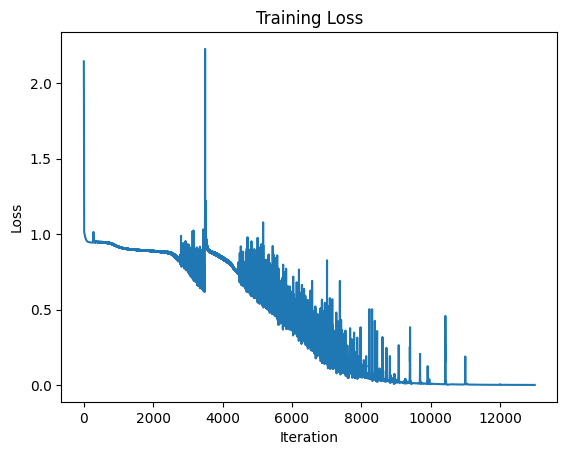

In [ ]:

%matplotlib inline
import torch
import torch.nn.functional as F

NUM_ATOMS = 29

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 32
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "mean"

NUM_ITERS = 13000
LR = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

keep = []
for i, d in enumerate(dataset):
    if d.num_nodes == NUM_ATOMS:
        keep.append(i)
    if len(keep) >= 1:
        break
filtered_dataset = dataset.index_select(keep)

real_mol = filtered_dataset[0]

print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)
print(f"Center of mass of real molecule positions: {real_pos.mean(dim=0)}")
print(f"Std of real molecule positions: {real_pos.std(dim=0)}")

one_hot_real_types = real_mol.real_atom_types.argmax(dim=-1)
one_hot_real_types = one_hot_real_types.to(device)
print(f"Real molecule atom types shape: {one_hot_real_types.shape}")

# Sample noise once with the same shape
# as the real molecules
pos_noise = torch.randn_like(real_mol.pos, device=device)
pos_noise = pos_noise - pos_noise.mean(dim=0)
pos_noise = pos_noise / pos_noise.std(dim=0)
dense_edge_index = real_mol.dense_edge_index
dense_edge_index = dense_edge_index.to(device)

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    # Forward pass
    gen_pos = model(pos_noise, one_hot_real_types, dense_edge_index)

    # Center generated positions
    gen_pos = gen_pos - gen_pos.mean(dim=0)

    # Since we are working with a single gen_mol and a single real_mol
    # we can just compute the drifting field as the differece,
    # but leave the other loss as reference
    V_pos = real_pos - gen_pos
    # V_pos = compute_euclidean_drifting_field(gen_pos, real_pos)

    target_pos = (gen_pos + V_pos).detach()
    loss = F.mse_loss(gen_pos, target_pos)

    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 500 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")
        evaluate_generated_molecules(gen_pos, one_hot_real_types, torch.zeros(gen_pos.size(0), dtype=torch.long, device=device))

plot_loss(loss_list)

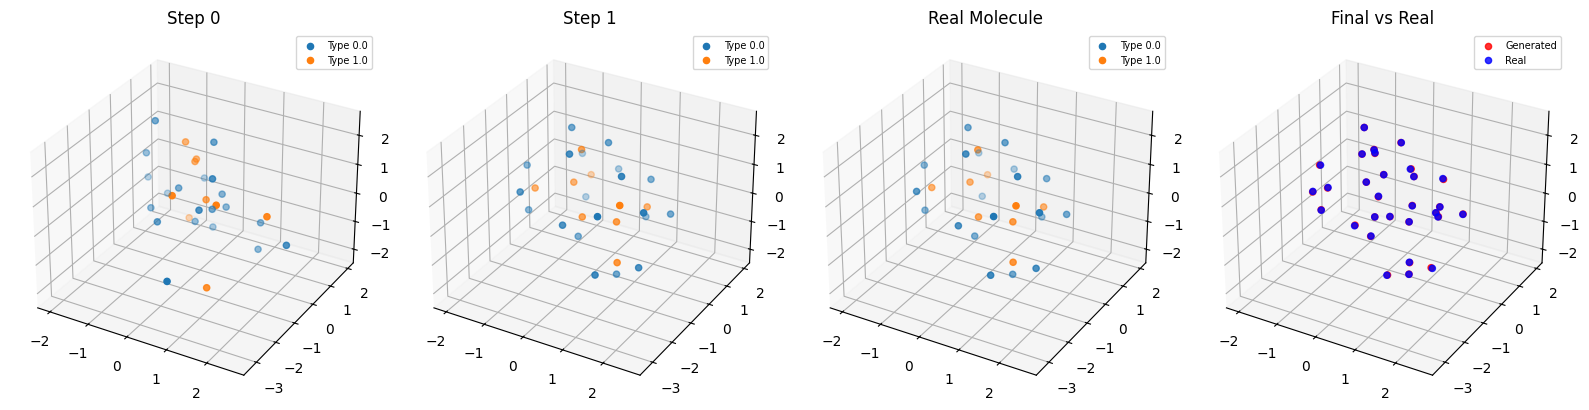

In [ ]:
gen_pos, pos_list = model(
    pos_noise, one_hot_real_types, dense_edge_index, return_change_in_pos=True
)
gen_pos = gen_pos - gen_pos.mean(dim=0)

# Center pos_list
pos_list = [p - p.mean(dim=0) for p in pos_list]

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=pos_list,
    gen_types=one_hot_real_types.to(torch.float32),
    real_pos=real_pos,
    real_types=one_hot_real_types.to(torch.float32),
    max_steps=len(pos_list)        # shows 6 evenly-spaced snapshots + real on the right
)

# Sample Multiple Noise ONCE

In [51]:
%matplotlib inline
import torch
import torch.nn.functional as F

NUM_ATOMS = 29
N_GEN_MOLS = 10

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 2
HIDDEN_NF = 32
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "mean"

NUM_ITERS = 13000
LR = 0.005

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

keep = []
for i, d in enumerate(dataset):
    if d.num_nodes == NUM_ATOMS:
        keep.append(i)
    if len(keep) >= 1:
        break
filtered_dataset = dataset.index_select(keep)

real_mol = filtered_dataset[0]

print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)

one_hot_real_types = real_mol.real_atom_types.argmax(dim=-1)
one_hot_real_types = one_hot_real_types.to(device)
print(f"Real molecule atom types shape: {one_hot_real_types.shape}")

real_pos_flattened = real_pos.view(1, -1)

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once with the same shape
# as the real molecules
batch_vec = torch.arange(N_GEN_MOLS, device=device).repeat_interleave(real_mol.num_nodes)
pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
pos_noise = center_positions_per_mol(pos_noise, batch_vec)
pos_noise = pos_noise / pos_noise.std(dim=0)
repeated_types = one_hot_real_types.repeat(N_GEN_MOLS)

dense_edge_index = real_mol.dense_edge_index
edge_index_list = []
for offset in range(N_GEN_MOLS):
    offset_edge_index = dense_edge_index + offset * real_mol.num_nodes
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)
dense_edge_index = dense_edge_index.to(device)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    # Forward pass
    gen_pos = model(pos_noise, repeated_types, dense_edge_index)

    # Center generated positions per molecule
    gen_pos = center_positions_per_mol(gen_pos, batch_vec)

    # Reshape to get right positions
    gen_pos = gen_pos.view(N_GEN_MOLS, -1)

    V_pos = compute_euclidean_drifting_field(gen_pos, real_pos_flattened, sigma=2.0)

    target_pos = (gen_pos + V_pos).detach()
    loss = F.mse_loss(gen_pos, target_pos)

    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 1 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()} | V_pos norm = {V_pos.view(-1, 3).norm(dim=1).mean().item():.4f}")

plot_loss(loss_list)

Number of nodes: 29
Real molecule atom types shape: torch.Size([29])
Iter 0: Loss = 0.08259353041648865 | V_pos norm = 0.2769
Iter 1: Loss = 0.08282960206270218 | V_pos norm = 0.2774
Iter 2: Loss = 0.0830664411187172 | V_pos norm = 0.2779
Iter 3: Loss = 0.0833040401339531 | V_pos norm = 0.2783
Iter 4: Loss = 0.08354217559099197 | V_pos norm = 0.2788
Iter 5: Loss = 0.08378130942583084 | V_pos norm = 0.2793
Iter 6: Loss = 0.08402119576931 | V_pos norm = 0.2798
Iter 7: Loss = 0.08426190912723541 | V_pos norm = 0.2802
Iter 8: Loss = 0.08450329303741455 | V_pos norm = 0.2807
Iter 9: Loss = 0.08474545180797577 | V_pos norm = 0.2812
Iter 10: Loss = 0.08498859405517578 | V_pos norm = 0.2817
Iter 11: Loss = 0.0852324590086937 | V_pos norm = 0.2822
Iter 12: Loss = 0.0854770615696907 | V_pos norm = 0.2826
Iter 13: Loss = 0.08572245389223099 | V_pos norm = 0.2831
Iter 14: Loss = 0.0859687551856041 | V_pos norm = 0.2836
Iter 15: Loss = 0.08621598780155182 | V_pos norm = 0.2841
Iter 16: Loss = 0.086

KeyboardInterrupt: 

# Align Output -> Multiple Noise

In [12]:
import torch
import torch.nn.functional as F

NUM_ATOMS = 29
N_GEN_MOLS = 10

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 2
HIDDEN_NF = 64
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "mean"

NUM_ITERS = 5000
LR = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

keep = []
for i, d in enumerate(dataset):
    if d.num_nodes == NUM_ATOMS:
        keep.append(i)
    if len(keep) >= 1:
        break
filtered_dataset = dataset.index_select(keep)

real_mol = filtered_dataset[0]

print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)

real_pos_flattened = real_pos.view(1, -1)

one_hot_real_types = real_mol.real_atom_types.argmax(dim=-1)
one_hot_real_types = one_hot_real_types.to(device)
print(f"Real molecule atom types shape: {one_hot_real_types.shape}")

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once with the same shape
# as the real molecules
batch_vec = torch.arange(N_GEN_MOLS, device=device).repeat_interleave(real_mol.num_nodes)
pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
pos_noise = center_positions_per_mol(pos_noise, batch_vec)
pos_noise = pos_noise / pos_noise.std(dim=0)
repeated_types = one_hot_real_types.repeat(N_GEN_MOLS)

dense_edge_index = real_mol.dense_edge_index
edge_index_list = []
for offset in range(N_GEN_MOLS):
    offset_edge_index = dense_edge_index + offset * real_mol.num_nodes
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)
dense_edge_index = dense_edge_index.to(device)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    # Forward pass
    gen_pos = model(pos_noise, repeated_types, dense_edge_index)

    # Center generated and align positions per molecule
    gen_pos = center_positions_per_mol(gen_pos, batch_vec)
    gen_pos = kabsch_align_pyg(
        gen_pos,
        real_pos.repeat(N_GEN_MOLS, 1),
        batch_vec,
        N_GEN_MOLS,
    )

    # Reshape to get right positions
    gen_pos = gen_pos.view(N_GEN_MOLS, -1)

    V_pos = compute_euclidean_drifting_field(gen_pos, real_pos_flattened)

    target_pos = (gen_pos + V_pos).detach()
    loss = F.mse_loss(gen_pos, target_pos)

    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 10 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

Number of nodes: 29
Real molecule atom types shape: torch.Size([29])
Iter 9: Loss = 0.0
Iter 19: Loss = 0.0
Iter 29: Loss = 0.0
Iter 39: Loss = 0.0
Iter 49: Loss = 0.0
Iter 59: Loss = 0.0
Iter 69: Loss = 0.0
Iter 79: Loss = 0.0
Iter 89: Loss = 0.0
Iter 99: Loss = 0.0
Iter 109: Loss = 0.0
Iter 119: Loss = 0.0


KeyboardInterrupt: 

In [ ]:
gen_pos, pos_list = model(
    pos_noise, repeated_types, dense_edge_index, return_change_in_pos=True
)
gen_pos = center_positions_per_mol(gen_pos, batch_vec)
gen_pos = kabsch_align_pyg(
    gen_pos,
    real_pos.repeat(N_GEN_MOLS, 1),
    batch_vec,
    N_GEN_MOLS,
)

gen_pos_flattened = gen_pos.view(N_GEN_MOLS, -1)
sorted_pos, closest_indices = get_sorted_mols(gen_pos_flattened, real_pos_flattened)

SELECTED_IDX = 9

selected_pos_list = []
for gen_pos_step in pos_list:
    gen_pos_step = gen_pos_step.view(N_GEN_MOLS, -1)
    ge_pos_step = gen_pos_step[SELECTED_IDX]
    gen_pos_step = ge_pos_step.view(-1, 3)
    gen_pos_step = gen_pos_step - gen_pos_step.mean(dim=0)
    gen_pos_step = kabsch_align(gen_pos_step, real_pos)
    selected_pos_list.append(gen_pos_step)

viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]

viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()
real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=selected_pos_list,
    gen_types=viz_types,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(selected_pos_list)
)